In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
# Read the df
df = pd.read_csv('../data/train.csv')
print(f"df shape: {df.shape}")
df.sample(5)

df shape: (891216, 16)


C:\Users\Akhil\AppData\Local\Temp\ipykernel_21492\777548732.py:2: DtypeWarning: Columns (0: PRN, 1: Carrier_Doppler_hz, 2: Pseudorange_m, 3: RX_time, 4: TOW, 5: Carrier_phase, 6: EC, 7: LC, 8: PC, 9: PIP, 10: PQP, 11: TCD, 12: CN0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/train.csv')


,time,channel,PRN,Carrier_Doppler_hz,Pseudorange_m,RX_time,TOW,Carrier_phase,EC,LC,PC,PIP,PQP,TCD,CN0,spoofed
139164,17395,ch4,12,3193.620507,24614675.127273,491892.38,491892.297894,-467917.071694,106071.06,107933.97,118077.11,-117533.56,-11316.571,3197.2522,46.2789,0
466360,58295,ch0,4,676.752698,-6663211.476667,174669.46,174669.482226,-19874.734928,133796.890625,120944.875,145348.328125,144982.234375,-10309.632812,613.296387,47.726173,1
582013,72751,ch5,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
638391,79798,ch7,7,3807.344588,21290573.905056,175099.62,175099.548982,-163742.470078,42812.691406,41601.511719,48780.425781,47938.089844,-9026.044922,3772.550537,42.40752,0
533421,66677,ch5,16,518.81151,23252880.032025,174837.2,174837.122437,-62187.52404,119239.890625,111378.515625,132552.90625,-132476.453125,4501.153809,508.945221,47.291363,0


In [3]:
import matplotlib.pyplot as plt

def plot_prn_vs_time(df, column, suptitle, ylabel, plot_type='scatter', color='red', s=20, special=None, ylim=None):
    prns = sorted(df['PRN'].dropna().unique())
    fig, axes = plt.subplots(len(prns)//4 + 1, 4, figsize=(20, len(prns) * 1.5))
    axes = axes.flatten()

    for i, prn in enumerate(prns):
        prn_df = df[df['PRN'] == prn].sort_values('time')

        if special == 'jumps':
            # 3-sigma jump detection
            col_diff = prn_df[column].diff().abs()
            threshold = col_diff.mean() + 3 * col_diff.std()
            jumps = prn_df[col_diff > threshold]

            axes[i].scatter(prn_df['time'], prn_df[column], color=color, s=s, zorder=5)
            axes[i].scatter(jumps['time'], jumps[column], color='black', s=30, zorder=6, label=f'Jump ({len(jumps)})')
            if len(jumps) > 0:
                axes[i].legend(fontsize=6)
        elif plot_type == 'scatter':
            axes[i].scatter(prn_df['time'], prn_df[column], s=s, color=color, zorder=3)
        elif plot_type == 'plot':
            axes[i].plot(prn_df['time'], prn_df[column], linewidth=0.8, color=color)
            if special == 'hline':
                axes[i].axhline(0, color='black', linewidth=0.5, linestyle='--')

        axes[i].set_title(f'PRN {int(prn)}', fontsize=9)
        axes[i].set_xlabel('time', fontsize=7)
        axes[i].set_ylabel(ylabel, fontsize=7)
        if ylim:
            axes[i].set_ylim(ylim)
        axes[i].tick_params(labelsize=6)

    # Hide unused subplots
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    fontsize = 20 if 'signal strength' in suptitle else 13
    plt.suptitle(suptitle, fontsize=fontsize, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

In [4]:
df.shape

(891216, 16)

In [5]:
df.columns

Index(['time', 'channel', 'PRN', 'Carrier_Doppler_hz', 'Pseudorange_m',
       'RX_time', 'TOW', 'Carrier_phase', 'EC', 'LC', 'PC', 'PIP', 'PQP',
       'TCD', 'CN0', 'spoofed'],
      dtype='str')

In [6]:
df.isnull().sum()
# No missing data

time                  0
channel               0
PRN                   0
Carrier_Doppler_hz    0
Pseudorange_m         0
RX_time               0
TOW                   0
Carrier_phase         0
EC                    0
LC                    0
PC                    0
PIP                   0
PQP                   0
TCD                   0
CN0                   0
spoofed               0
dtype: int64

In [7]:
print("Start Time",df["time"].min())
print("End Time",df["time"].max())

Start Time 0
End Time 111401


Imbalanced classes 

In [8]:
df['spoofed'].value_counts()

spoofed
0    763888
1    127328
Name: count, dtype: int64

In [9]:
# First 8 rows are initializatiion rows and contain no information 
df['PRN'][8:].unique()

array(['0', '6', '2', '12', '19', 6, 0, 12, 19, 25, 11, 2, 17, 3, 24, 26,
       16, 9, 31, 4, 27, 8, 7, 20], dtype=object)

As some channels have datatype string instead of int they will be converted into integer and also drop the first 8 initialization rows

In [10]:
# Drop initialization rows
df = df[~df['PRN'].astype(str).str.startswith('ch')].reset_index(drop=True)

# Convert ALL columns to numeric
cols_to_convert = ['time', 'PRN', 'Carrier_Doppler_hz', 'Pseudorange_m', 
                   'RX_time', 'TOW', 'Carrier_phase', 
                   'EC', 'LC', 'PC', 'PIP', 'PQP', 'TCD', 'CN0']

df[cols_to_convert] = df[cols_to_convert].apply(pd.to_numeric, errors='coerce')

# PRN and channel should be integers specifically
df['PRN'] = df['PRN'].astype(int)

In [11]:
df['PRN'][8:].unique()

array([ 0,  6,  2, 12, 19, 25, 11, 17,  3, 24, 26, 16,  9, 31,  4, 27,  8,
        7, 20])

In [12]:
df['channel'].unique()

<StringArray>
['ch0', 'ch1', 'ch2', 'ch3', 'ch4', 'ch5', 'ch6', 'ch7']
Length: 8, dtype: str

Early-Late Correlator Differnce(ELCD)=(EC − LC) / PC

In [13]:
df['ELCD']=(df['EC']-df['LC'])/df['PC']

In a genuine signal, EC ≈ LC . Spoofing distorts this symmetry because the fake signal's code structure is subtly different. The ratio (EC-LC)/PC are powerful spoofing indicators. Sudden changes in the ratio and huge deflecton from 0 is a indictor for a fake signal.

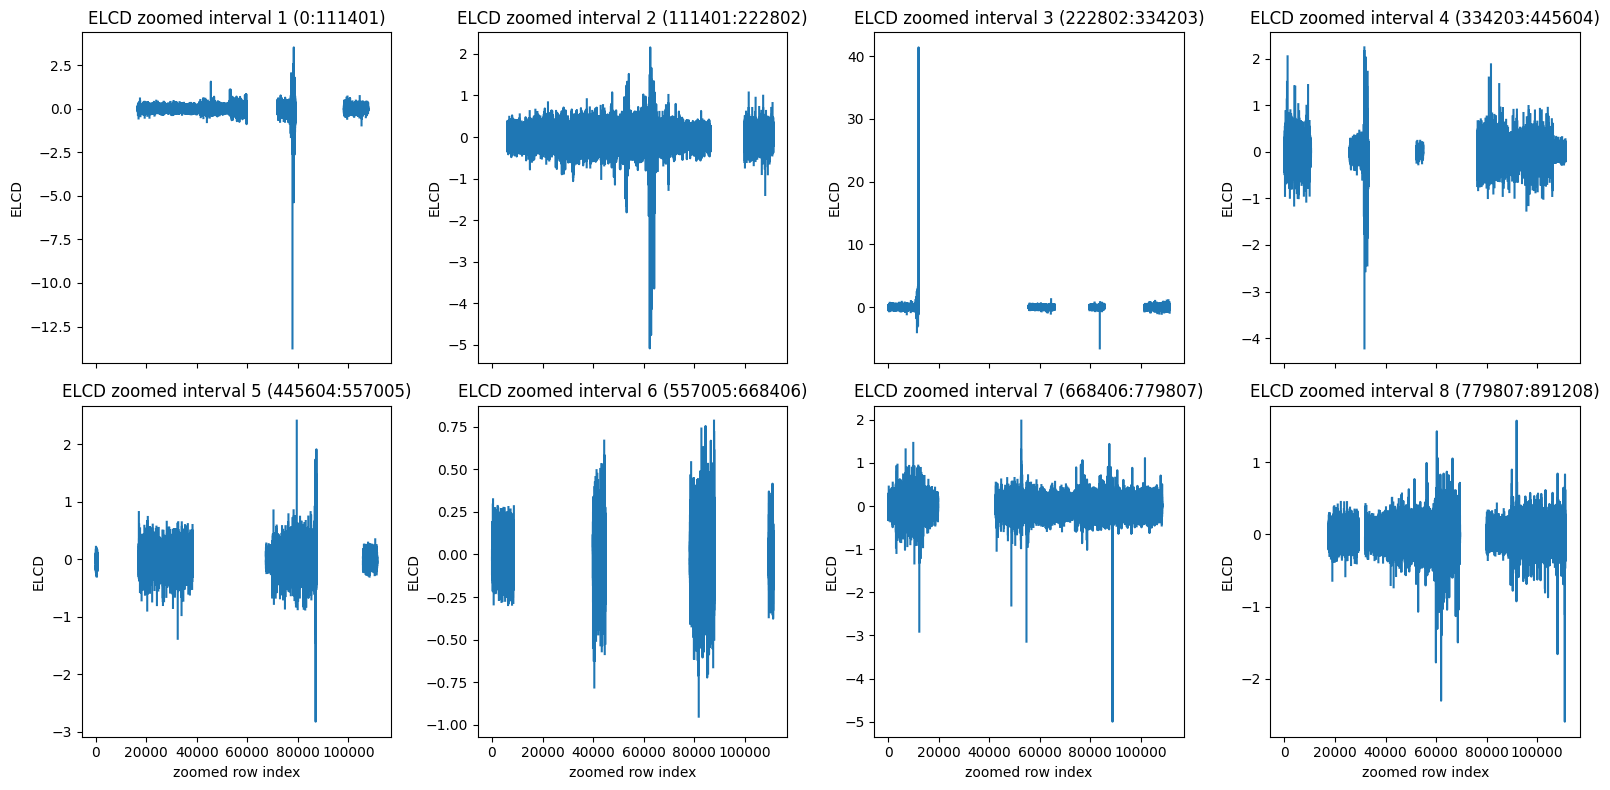

In [14]:
interval_count = 8
interval_len = len(df) // interval_count
fig, axs = plt.subplots(2, 4, figsize=(16, 8), sharex=True)
axs = axs.flatten()

for i in range(interval_count):
    start = i * interval_len
    end = start + interval_len
    axs[i].plot(df['ELCD'].iloc[start:end].reset_index(drop=True))
    axs[i].set_title(f'ELCD zoomed interval {i + 1} ({start}:{end})')
    axs[i].set_ylabel('ELCD')

for ax in axs[4:]:
    ax.set_xlabel('zoomed row index')

plt.tight_layout()

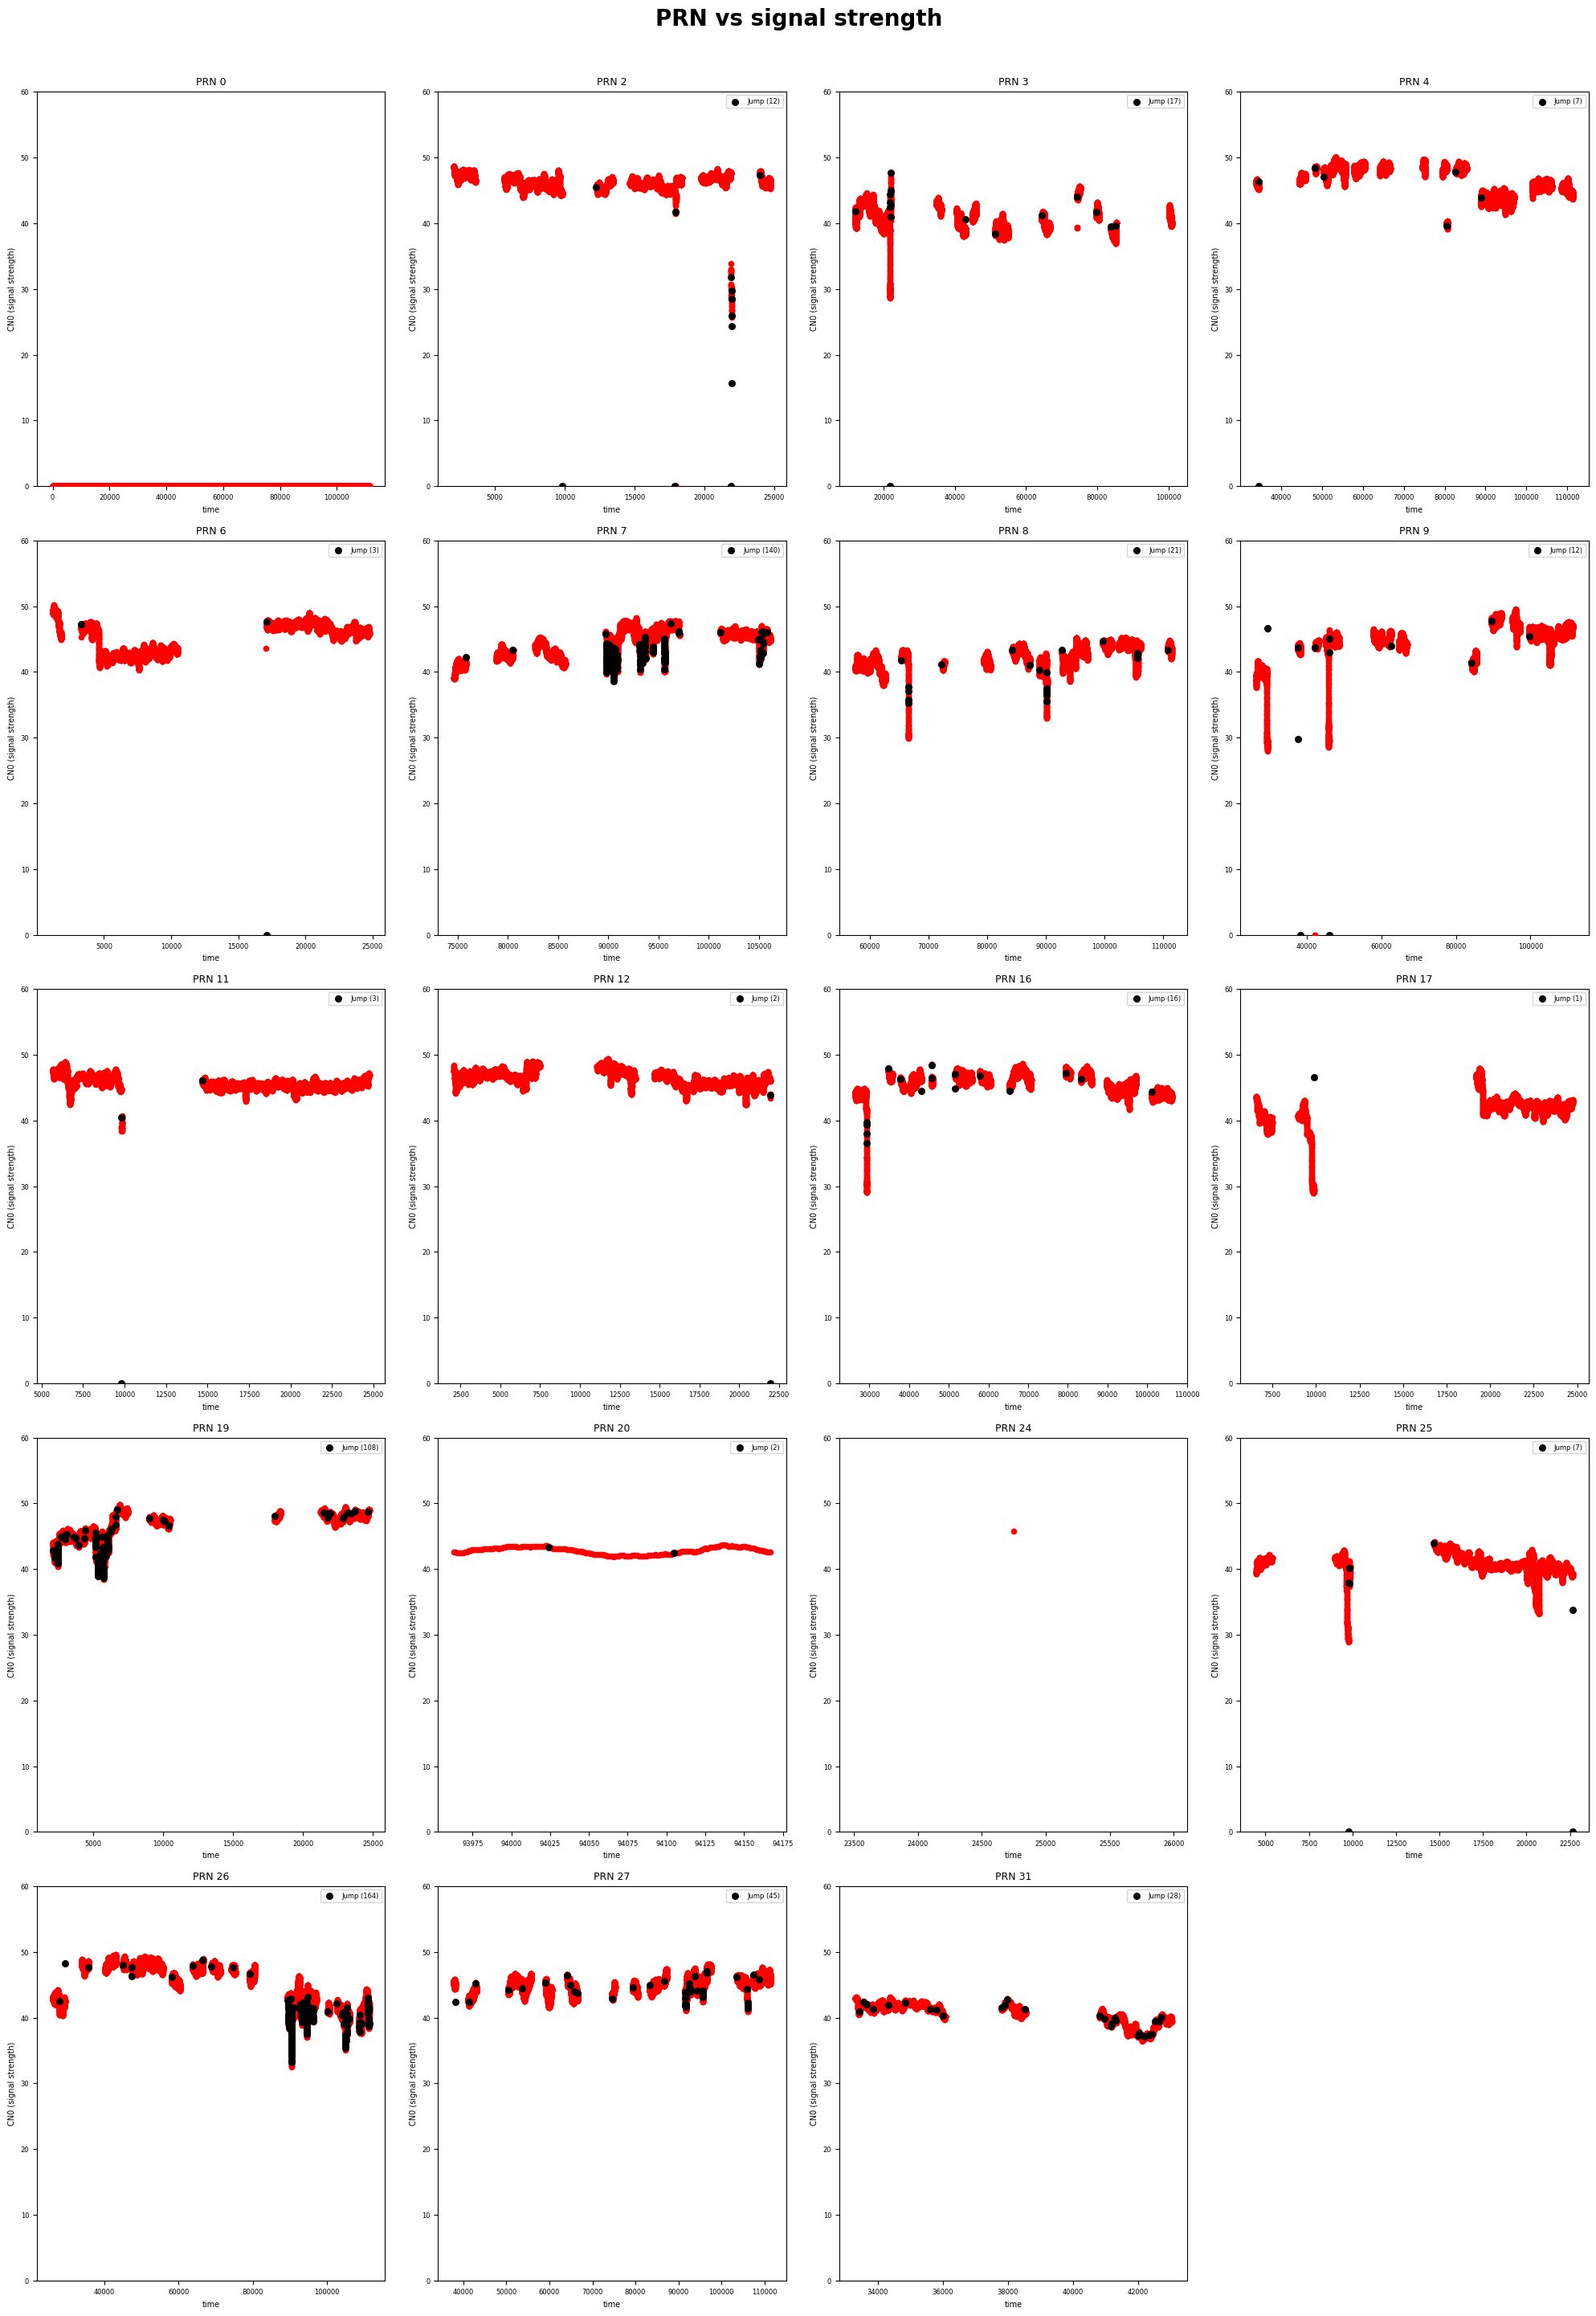

In [15]:
plot_prn_vs_time(df, 'CN0', 'PRN vs signal strength', 'CN0 (signal strength)', plot_type='scatter', color='red', s=20, special='jumps', ylim=(0,60))

When there is sudden jumps it indicates that the satellite distance suddenly increased or decreased .If there is gap 

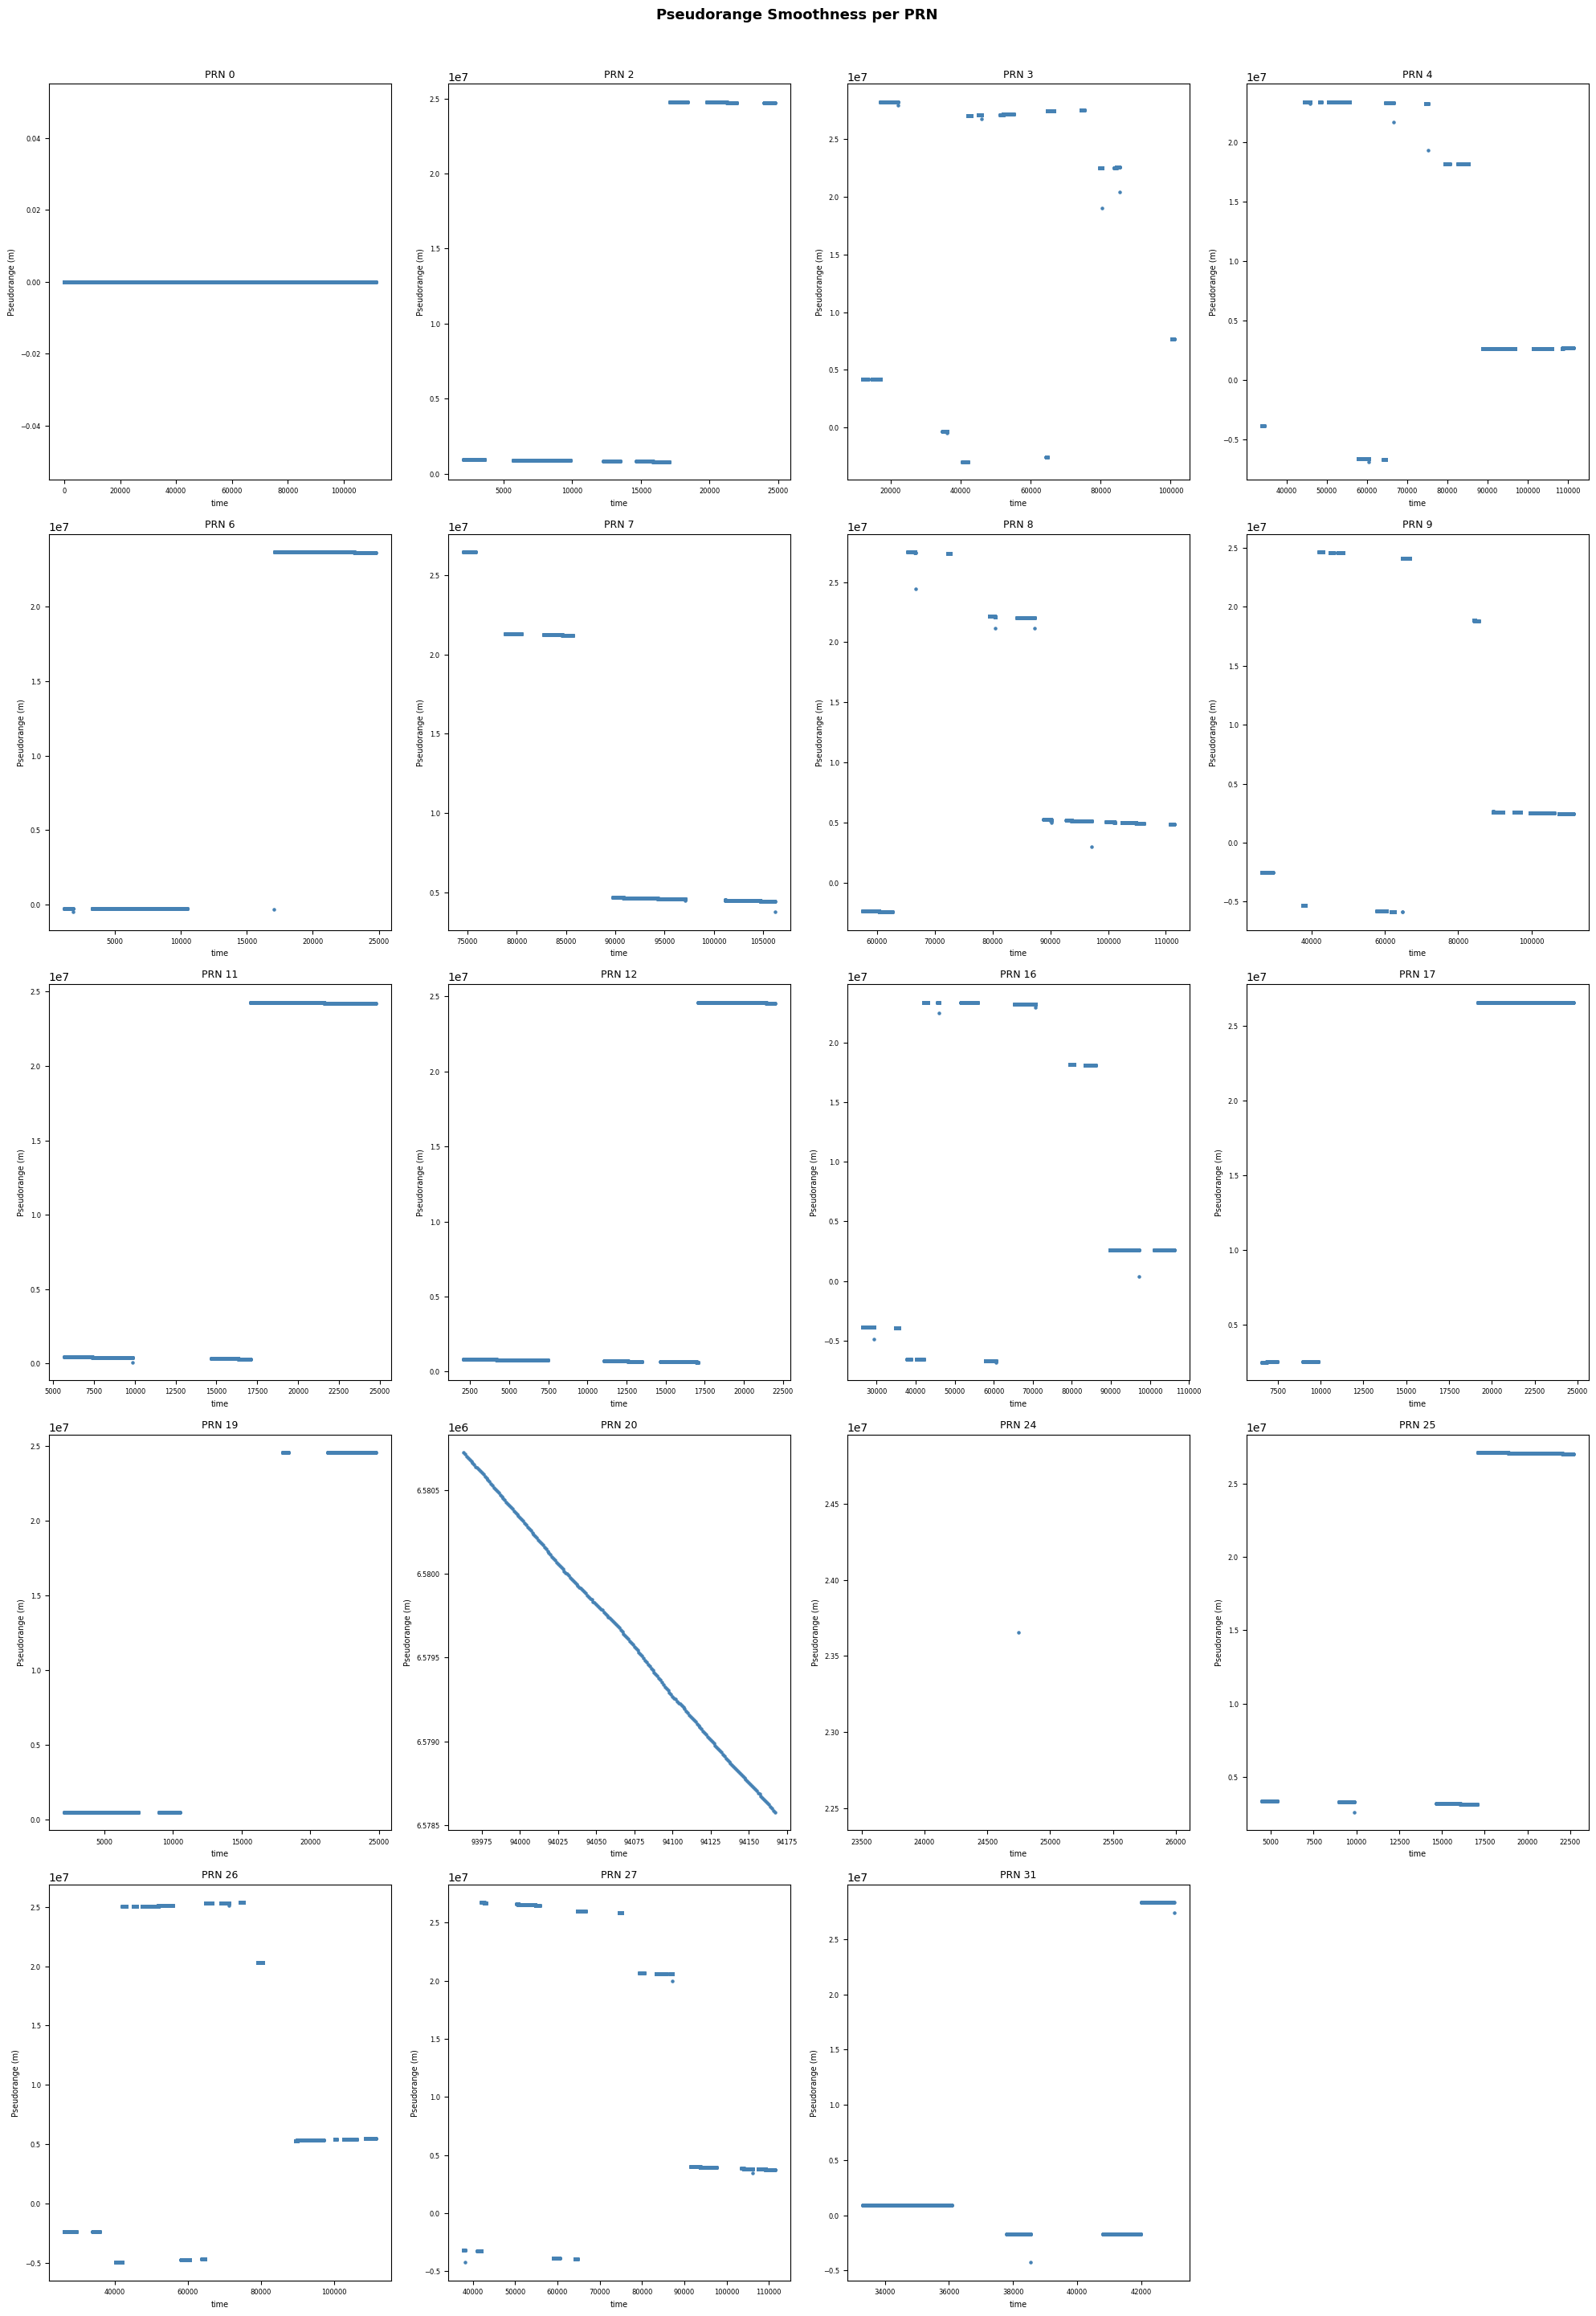

In [16]:
plot_prn_vs_time(df, 'Pseudorange_m', 'Pseudorange Smoothness per PRN ', 'Pseudorange (m)', plot_type='scatter', color='steelblue', s=5)

ajknaf


In [17]:
df['TOW_RX_diff'] = df['TOW'] - df['RX_time']

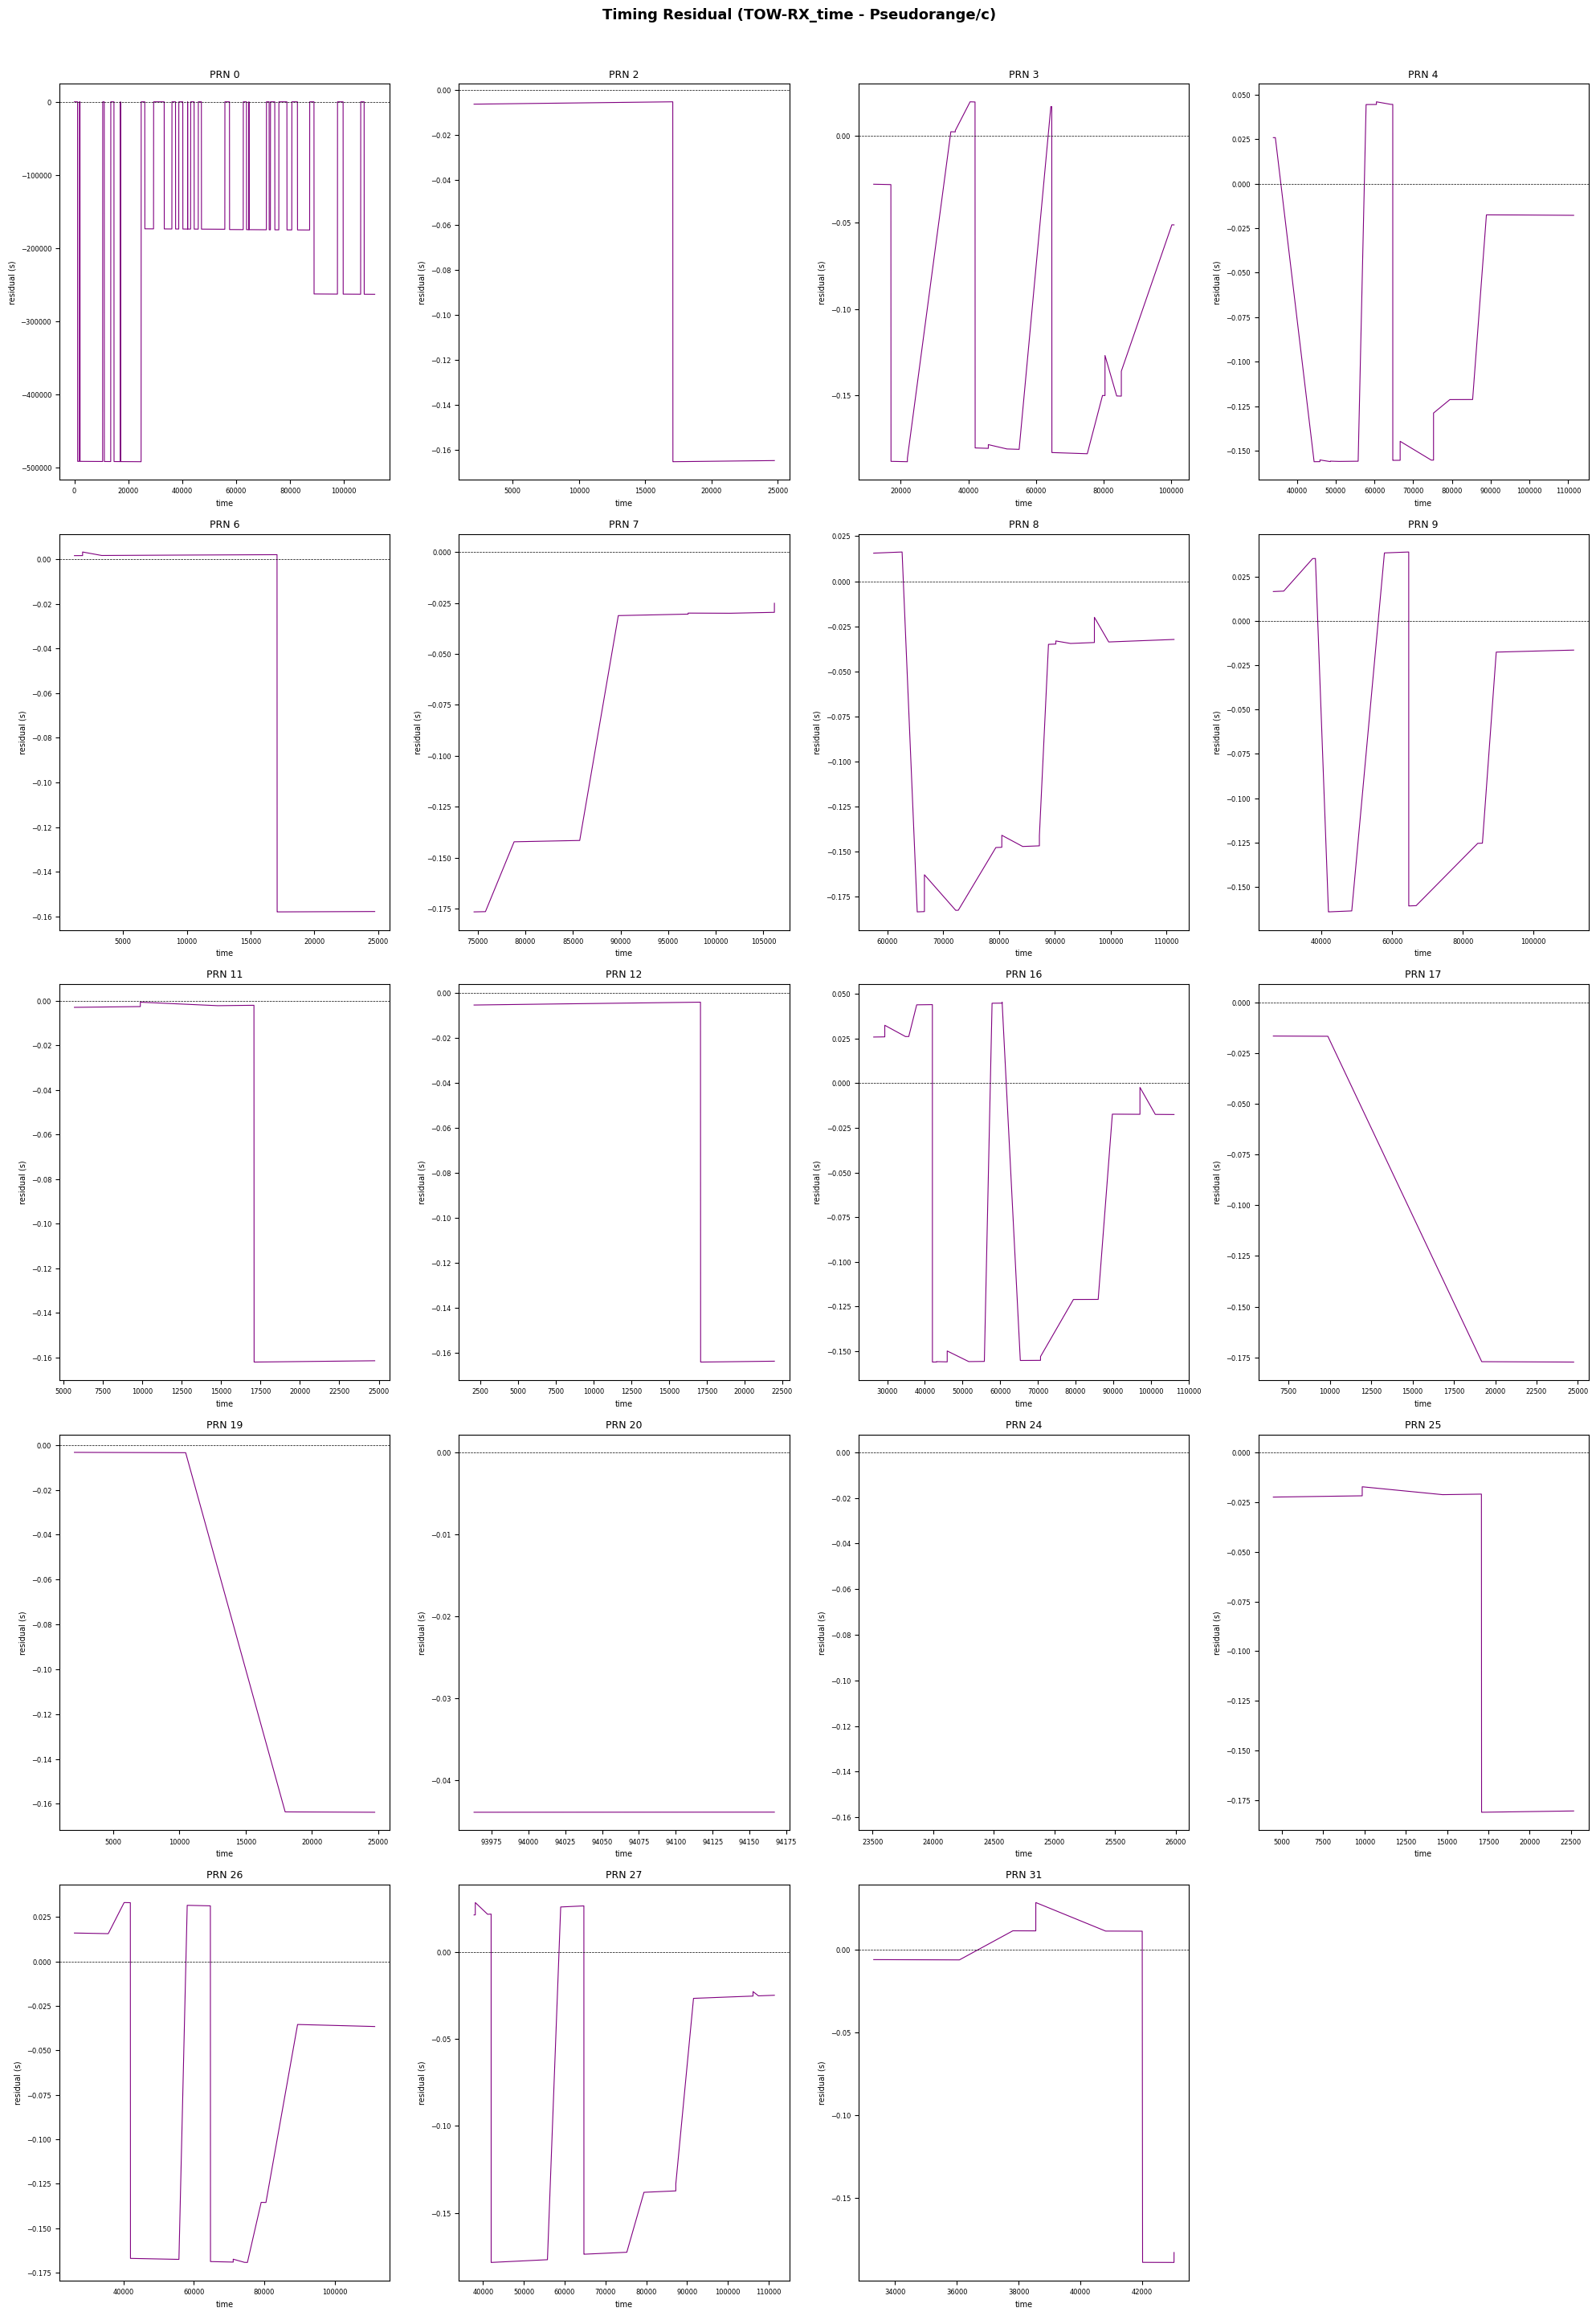

In [18]:
# Speed of light
c = 299792458  # m/s

df['TOW_RX_diff'] = df['TOW'] - df['RX_time']
df['expected_propagation'] = df['Pseudorange_m'] / c
prns = sorted(df['PRN'].dropna().unique())
# The key feature — should be near zero for genuine signals
df['timing_residual'] = df['TOW_RX_diff'] - df['expected_propagation']

plot_prn_vs_time(df, 'timing_residual', 'Timing Residual (TOW-RX_time - Pseudorange/c)', 'residual (s)', plot_type='plot', color='purple', special='hline')

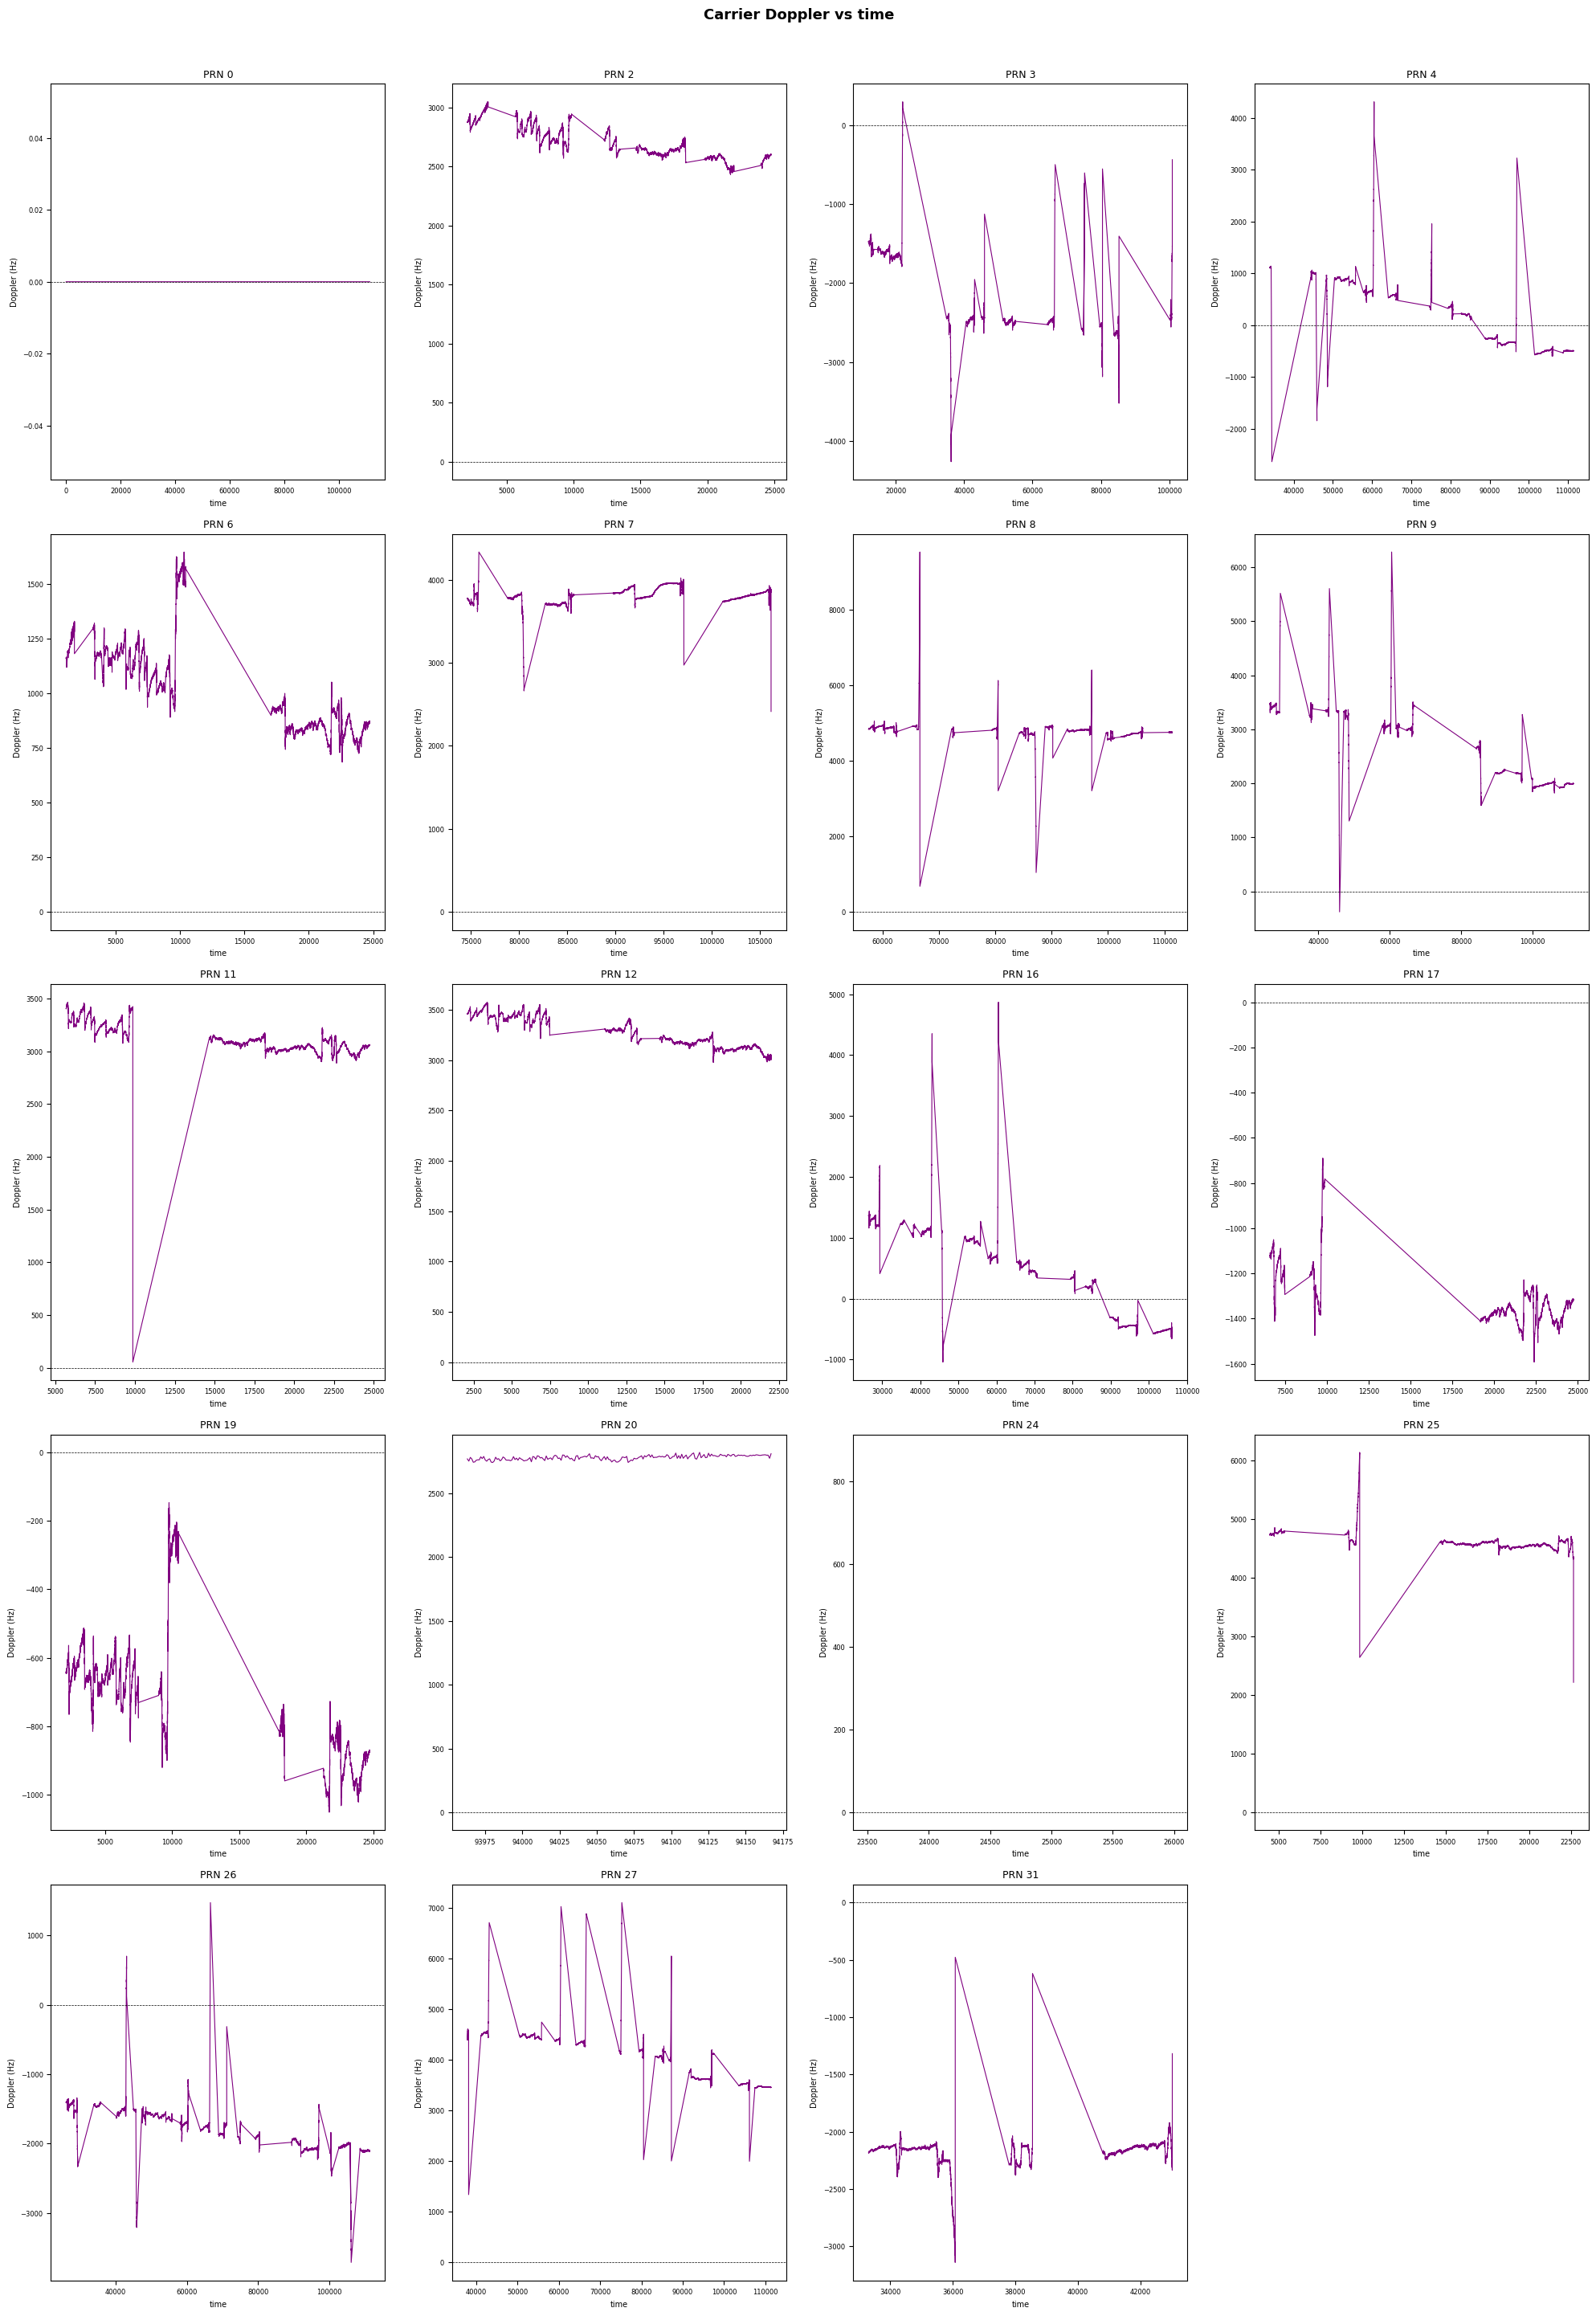

In [19]:
plot_prn_vs_time(df, 'Carrier_Doppler_hz', 'Carrier Doppler vs time', 'Doppler (Hz)', plot_type='plot', color='purple', special='hline')